Setup complete. Fixed seed: 42
Found 143 PDF files in raw directory.


Extracting PDF text: 100%|██████████| 143/143 [02:01<00:00,  1.18it/s]



Successfully extracted text from 143 PDFs.
Raw data saved to: /Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed/submissions_raw.csv
Computing extended raw text metrics...

=== RAW CORPUS OVERALL SUMMARY ===
Total Documents: 143
Total Raw Words (Tokens): 535,709
Total Characters: 3,809,735
Average Words per Document: 3746.22 (Std: 5645.99)
Average Lexical Diversity (Raw TTR): 0.3697

=== ADVANCED RAW TEXT METRICS (DESCRIPTIVE STATS) ===
                               mean           std        min           50%  \
word_count              3746.216783   5645.991148  11.000000   2170.000000   
char_count             26641.503497  38888.869984  71.000000  16048.000000   
line_count               381.909091    552.485433   2.000000    232.000000   
unique_word_count       1074.727273    979.390204  11.000000    842.000000   
avg_word_length            7.117404      0.439699   6.201940      7.106764   
lexical_diversity_ttr    

/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/.venv/lib/python3.12/site-packages/seaborn/categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


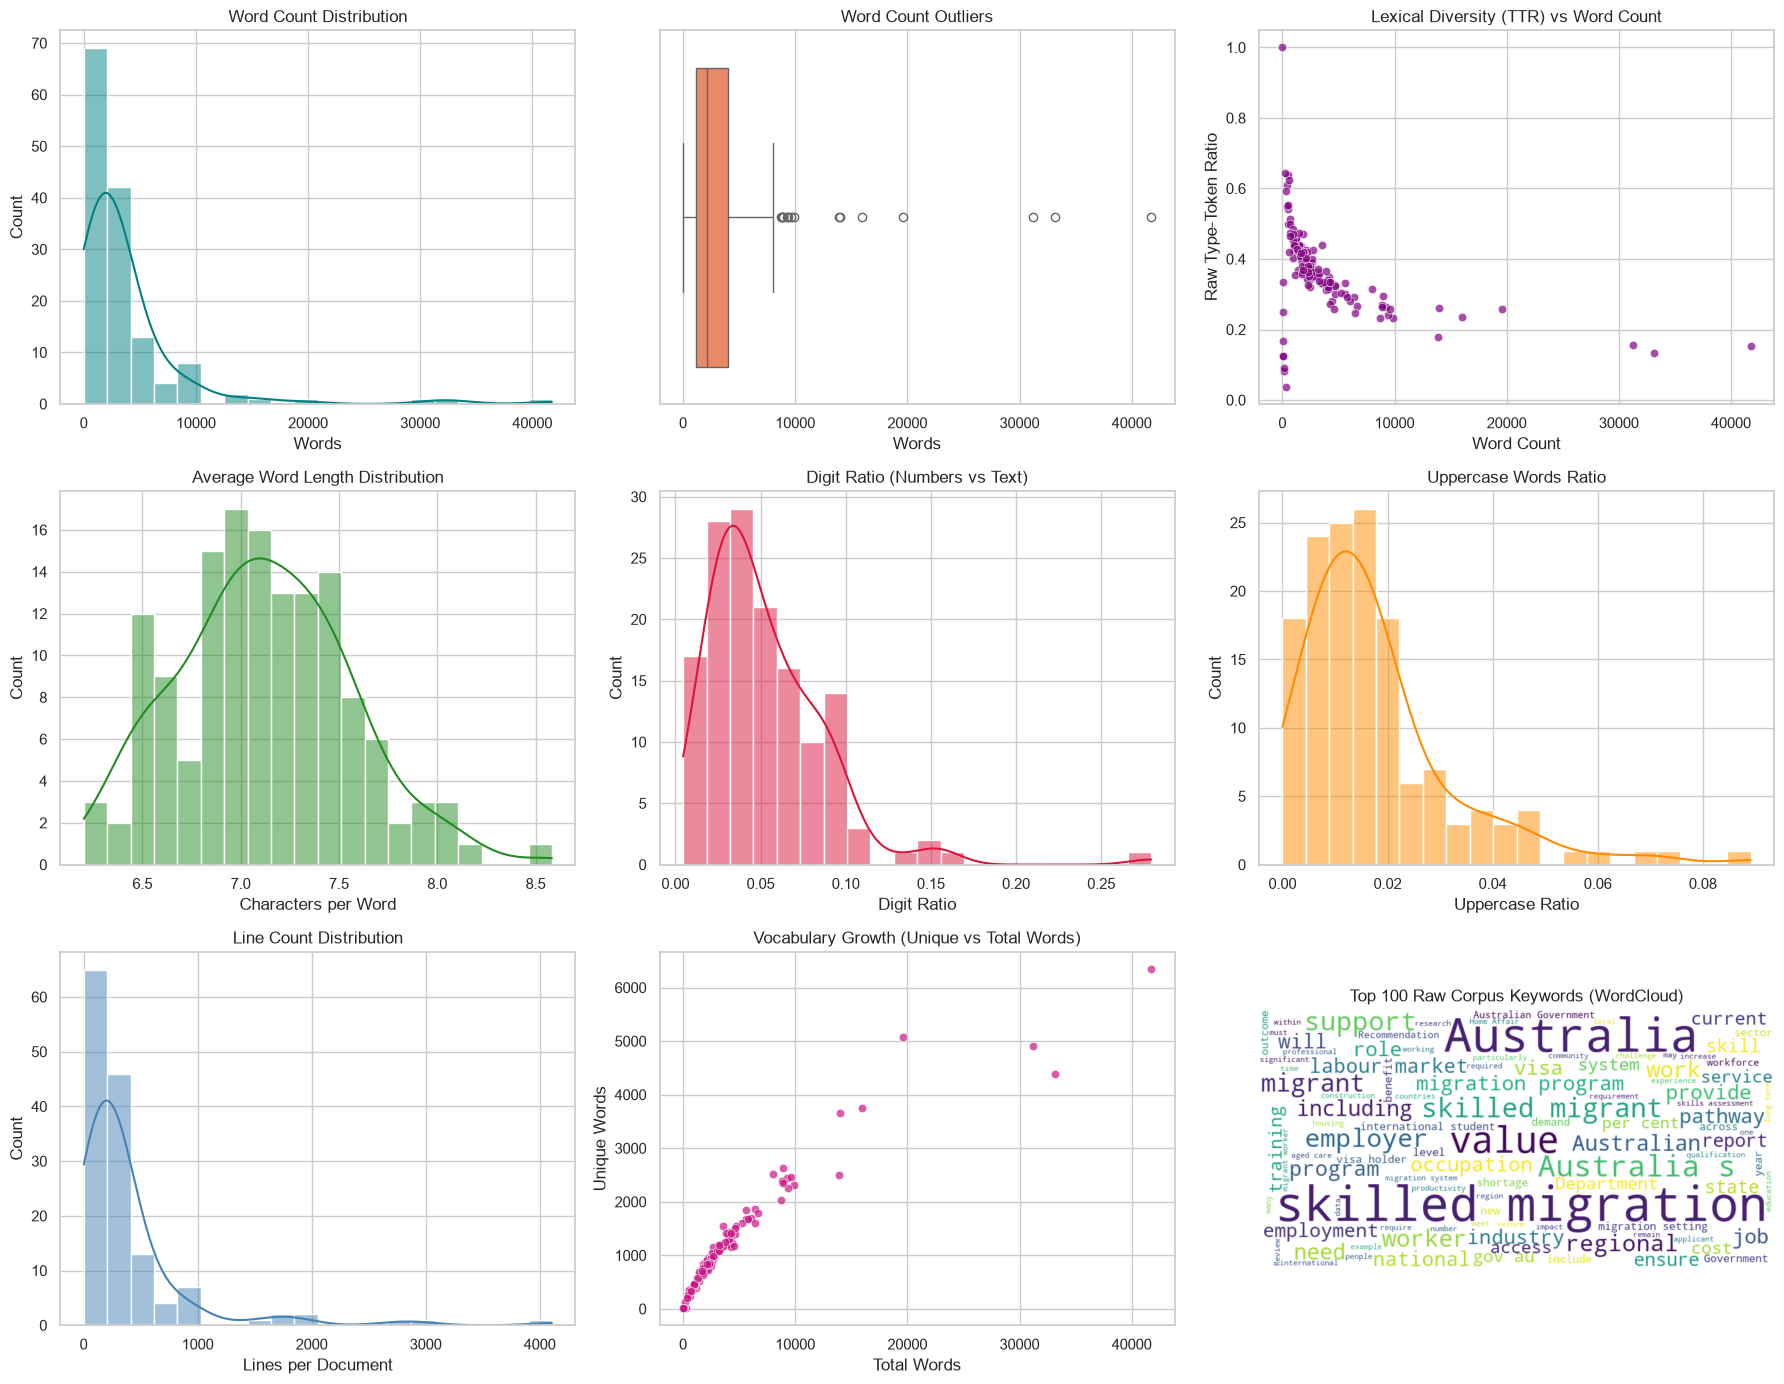

Boilerplate lines detected (appear in >=30% of docs): 1
  - inquiry into the value of skilled migration to australia

Average % of words removed by URL/boilerplate stripping: 10.17%
(Should be a small percentage, roughly 1-10%. If much higher, min_doc_fraction is too loose.)
Cleaning and lemmatizing text corpus...


Cleaning: 100%|██████████| 143/143 [00:14<00:00,  9.64it/s]


Text preprocessing complete!
CHECKPOINT 1: TEXT CLEANING QUALITY
Average % of words removed during cleaning: 44.56%
If this is above ~70-75%, the cleaning may be too aggressive.

--- Sample raw vs. clean text (first 2 documents) ---

[Document 0] RAW (first 200 chars):
Inquiry into the value of skilled migration to Australia
Submission 106
Inquiry into the value of skilled migration to Australia
Submission 106
Who we are
The Federation of Ethnic Communities’ Council

[Document 0] CLEAN (first 200 chars):
federation ethnic community council fecca national peak body represent people culturally linguistically diverse cald community organisation across membership state territory regional ethnic community 

[Document 1] RAW (first 200 chars):
Inquiry into the value of skilled migration to Australia
Submission 112
Inquiry into the value of
Skilled Migration to
Australia
Submission by the Australian Council of Trade Unions
ACTU Submission, D

[Document 1] CLEAN (first 200 chars):
value skille

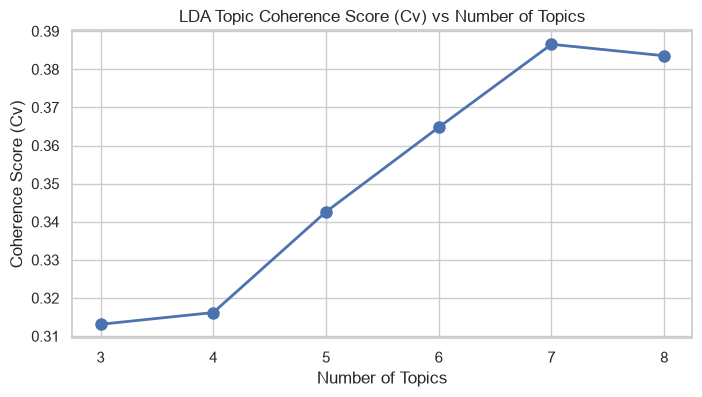


Optimal number of topics selected: 7 (Cv = 0.3866)

=== TOP 10 KEYWORDS PER TOPIC (LDA - 7 TOPICS) ===

Topic 1:
 -> exploitation, condition, strategy, reform, risk, protection, recognition, domestic, right, disability

Topic 2:
 -> settlement, small_business, infrastructure, immigration, strategy, retention, reform, highlight, construction, regional_area

Topic 3:
 -> nurse, age_care, care, nursing, practice, healthcare, automotive, member, recruitment, council

Topic 4:
 -> applicant, application, immigration, assessment, trade, age, recognition, standard, stream, employer_sponsor

Topic 5:
 -> south, construction, trade, reform, international_student, underutilisation, skilled_migration_program, infrastructure, state, low

Topic 6:
 -> graduate, international_student, student, university, research, study, application, pay, skill_assessment, per_cent

Topic 7:
 -> palm_scheme, palm_worker, palm, tax, scheme, pacific, pay, wage, partner, resident
CHECKPOINT 5: TOPIC QUALITY AND DISTR


Final processed dataset saved successfully at:
/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed/submissions_processed.csv


In [1]:
# %% [markdown]
# # Skilled Migration Submissions — Topic Modeling Pipeline (LDA)
#
# Full pipeline: PDF extraction -> raw text statistics -> cleaning (with
# boilerplate removal, contraction fix, POS-aware lemmatization) -> bigram/
# trigram detection -> document filtering -> dictionary/corpus -> LDA
# training with num_topics search -> visualization -> human validation.
#
# Every major block prints a CHECKPOINT so you can review the quality of
# that step before moving to the next one.

# %%
# ======================================================================
# 0. IMPORTS, SEEDS, PATHS
# ======================================================================
import json
import os
import random
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag

import pdfplumber

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from IPython.display import HTML, display

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import gensim
from gensim import corpora
from gensim.models import CoherenceModel, LdaModel, Phrases
from gensim.models.phrases import Phraser
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# --- Reproducibility ---
# Fix seeds across every relevant generator so runs are comparable
# (avoids the earlier issue of coherence scores that looked "identical
# by coincidence" or "different for no reason" between runs).
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# --- Paths ---
RAW_DATA_PATH = Path(
    "/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/raw"
)
PROCESSED_DATA_PATH = Path(
    "/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed"
)
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

# --- Download required NLTK resources (includes the POS tagger, which was missing before) ---
for resource in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
                  "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass  # resource names vary slightly across nltk versions; not critical if one fails

print("Setup complete. Fixed seed:", SEED)

# %%
# ======================================================================
# 1. EXTRACT TEXT FROM PDFs
# ======================================================================
def extract_pdf_text(filepath):
    """Extracts plain text from a PDF using pdfplumber."""
    full_text = []
    try:
        with pdfplumber.open(filepath) as pdf:
            for page in pdf.pages:
                text = page.extract_text()
                if text:
                    full_text.append(text)
        return "\n".join(full_text)
    except Exception as e:
        print(f"Error reading {filepath.name}: {e}")
        return None


pdf_files = list(RAW_DATA_PATH.glob("*.[pP][dD][fF]"))
print(f"Found {len(pdf_files)} PDF files in raw directory.")

records = []
for pdf_path in tqdm(pdf_files, desc="Extracting PDF text"):
    content = extract_pdf_text(pdf_path)
    if content:
        records.append({
            "archivo": pdf_path.name,
            "tamano_bytes": pdf_path.stat().st_size,
            "texto_raw": content,
        })

df = pd.DataFrame(records)
print(f"\nSuccessfully extracted text from {len(df)} PDFs.")

raw_csv_path = PROCESSED_DATA_PATH / "submissions_raw.csv"
df.to_csv(raw_csv_path, index=False)
print(f"Raw data saved to: {raw_csv_path}")

# %%
# ======================================================================
# 2. RAW TEXT STATISTICS AND VISUALIZATION
# ======================================================================
print("Computing extended raw text metrics...")

df["char_count"] = df["texto_raw"].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
df["word_count"] = df["texto_raw"].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
df["line_count"] = df["texto_raw"].apply(lambda x: len(str(x).splitlines()) if pd.notna(x) else 0)

df["unique_word_count"] = df["texto_raw"].apply(
    lambda x: len(set(str(x).lower().split())) if pd.notna(x) else 0
)
df["avg_word_length"] = df.apply(
    lambda row: row["char_count"] / row["word_count"] if row["word_count"] > 0 else 0, axis=1
)
df["lexical_diversity_ttr"] = df.apply(
    lambda row: row["unique_word_count"] / row["word_count"] if row["word_count"] > 0 else 0, axis=1
)

df["uppercase_word_count"] = df["texto_raw"].apply(
    lambda x: len([w for w in str(x).split() if w.isupper() and len(w) > 1]) if pd.notna(x) else 0
)
df["digit_count"] = df["texto_raw"].apply(lambda x: len(re.findall(r"\d+", str(x))) if pd.notna(x) else 0)
df["punctuation_count"] = df["texto_raw"].apply(
    lambda x: len(re.findall(r"[^\w\s]", str(x))) if pd.notna(x) else 0
)

df["digit_ratio"] = df["digit_count"] / df["word_count"].replace(0, 1)
df["uppercase_ratio"] = df["uppercase_word_count"] / df["word_count"].replace(0, 1)

print("\n=== RAW CORPUS OVERALL SUMMARY ===")
print(f"Total Documents: {len(df):,}")
print(f"Total Raw Words (Tokens): {df['word_count'].sum():,}")
print(f"Total Characters: {df['char_count'].sum():,}")
print(f"Average Words per Document: {df['word_count'].mean():.2f} (Std: {df['word_count'].std():.2f})")
print(f"Average Lexical Diversity (Raw TTR): {df['lexical_diversity_ttr'].mean():.4f}")

print("\n=== ADVANCED RAW TEXT METRICS (DESCRIPTIVE STATS) ===")
metrics_to_show = [
    "word_count", "char_count", "line_count", "unique_word_count",
    "avg_word_length", "lexical_diversity_ttr", "digit_ratio", "uppercase_ratio",
]
print(df[metrics_to_show].describe().T[["mean", "std", "min", "50%", "max"]])

print("\n=== EXTREME DOCUMENTS IDENTIFICATION (diagnostic only, real filtering happens later) ===")
short_docs = df[df["word_count"] < 100][["archivo", "word_count", "char_count"]]
print(f"Documents with fewer than 100 words: {len(short_docs)}")
if len(short_docs) > 0:
    print(short_docs.head())

high_digit_docs = df[df["digit_ratio"] > 0.1][["archivo", "word_count", "digit_ratio"]]
print(f"\nDocuments with >10% digits (potential data tables): {len(high_digit_docs)}")
if len(high_digit_docs) > 0:
    print(high_digit_docs.head())

# --- 3x3 visualization panel ---
print("\nGenerating extended visualization panel including WordCloud...")
all_text = " ".join(df["texto_raw"].dropna().tolist())
custom_wc_stopwords = set(STOPWORDS).union({
    "http", "https", "www", "com", "pdf", "page", "subclass", "submission",
    "inquiry", "committee",
})

wc = WordCloud(
    width=800, height=400, background_color="white",
    stopwords=custom_wc_stopwords, max_words=100, colormap="viridis", random_state=SEED,
).generate(all_text)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

sns.histplot(df["word_count"], kde=True, ax=axes[0, 0], color="teal", bins=20)
axes[0, 0].set_title("Word Count Distribution")
axes[0, 0].set_xlabel("Words")

sns.boxplot(x=df["word_count"], ax=axes[0, 1], color="coral")
axes[0, 1].set_title("Word Count Outliers")
axes[0, 1].set_xlabel("Words")

sns.scatterplot(data=df, x="word_count", y="lexical_diversity_ttr", ax=axes[0, 2], alpha=0.7, color="purple")
axes[0, 2].set_title("Lexical Diversity (TTR) vs Word Count")
axes[0, 2].set_xlabel("Word Count")
axes[0, 2].set_ylabel("Raw Type-Token Ratio")

sns.histplot(df["avg_word_length"], kde=True, ax=axes[1, 0], color="forestgreen", bins=20)
axes[1, 0].set_title("Average Word Length Distribution")
axes[1, 0].set_xlabel("Characters per Word")

sns.histplot(df["digit_ratio"], kde=True, ax=axes[1, 1], color="crimson", bins=20)
axes[1, 1].set_title("Digit Ratio (Numbers vs Text)")
axes[1, 1].set_xlabel("Digit Ratio")

sns.histplot(df["uppercase_ratio"], kde=True, ax=axes[1, 2], color="darkorange", bins=20)
axes[1, 2].set_title("Uppercase Words Ratio")
axes[1, 2].set_xlabel("Uppercase Ratio")

sns.histplot(df["line_count"], kde=True, ax=axes[2, 0], color="steelblue", bins=20)
axes[2, 0].set_title("Line Count Distribution")
axes[2, 0].set_xlabel("Lines per Document")

sns.scatterplot(data=df, x="word_count", y="unique_word_count", ax=axes[2, 1], color="mediumvioletred", alpha=0.7)
axes[2, 1].set_title("Vocabulary Growth (Unique vs Total Words)")
axes[2, 1].set_xlabel("Total Words")
axes[2, 1].set_ylabel("Unique Words")

axes[2, 2].imshow(wc, interpolation="bilinear")
axes[2, 2].axis("off")
axes[2, 2].set_title("Top 100 Raw Corpus Keywords (WordCloud)")

plt.tight_layout()
plt.show()

# %%
# ======================================================================
# 3. URL / EMAIL / BOILERPLATE REMOVAL
# ======================================================================
# FIX #2 (new): strip URLs and email addresses BEFORE symbol stripping.
# Without this, something like "unionsnsw.org.au" gets shattered into
# "unionsnsw org au" by the later regex, and the phrase detector then
# glues it back together into a meaningless token like "unionsnsw_org".
URL_PATTERN = re.compile(r"(https?://\S+|www\.\S+|\S+\.(?:com|org|gov|edu|au|net)\.?\S*)", re.IGNORECASE)
EMAIL_PATTERN = re.compile(r"\S+@\S+\.\S+")


def strip_urls_and_emails(text):
    if not isinstance(text, str):
        return text
    text = EMAIL_PATTERN.sub(" ", text)
    text = URL_PATTERN.sub(" ", text)
    return text


# FIX #1 (new): the inquiry title doesn't only appear as a repeated full
# line (header/cover page) — it's also embedded mid-paragraph inside many
# submissions' own introductions (e.g. "...responds to the Inquiry into
# the Value of Skilled Migration to Australia..."). A line-level boilerplate
# detector alone won't catch that. We handle full-line repeats here, and
# handle the embedded-phrase case later at the bigram/token level (step 6).

def normalize_line(line):
    return re.sub(r"\s+", " ", line.strip().lower())


def find_boilerplate_lines(texts, min_doc_fraction=0.3, min_len=15):
    """Finds (normalized) lines that appear in at least min_doc_fraction
    of the documents. These are almost always headers, footers or repeated
    titles, not real content."""
    line_doc_counts = Counter()
    n_docs = len(texts)
    for text in texts:
        if not isinstance(text, str):
            continue
        lines = {normalize_line(l) for l in text.splitlines() if len(l.strip()) >= min_len}
        for line in lines:
            line_doc_counts[line] += 1
    threshold = max(2, int(n_docs * min_doc_fraction))
    boilerplate = {line for line, count in line_doc_counts.items() if count >= threshold}
    return boilerplate


def remove_boilerplate(text, boilerplate_set):
    if not isinstance(text, str):
        return text
    kept_lines = [l for l in text.splitlines() if normalize_line(l) not in boilerplate_set]
    return "\n".join(kept_lines)


df["texto_sin_urls"] = df["texto_raw"].apply(strip_urls_and_emails)

boilerplate_lines = find_boilerplate_lines(df["texto_sin_urls"].tolist(), min_doc_fraction=0.3)
print(f"Boilerplate lines detected (appear in >=30% of docs): {len(boilerplate_lines)}")
for line in list(boilerplate_lines)[:10]:
    print("  -", line[:100])

df["texto_sin_boilerplate"] = df["texto_sin_urls"].apply(lambda x: remove_boilerplate(x, boilerplate_lines))

# Also strip loose "Submission N" mentions that don't form a full repeated line.
df["texto_sin_boilerplate"] = df["texto_sin_boilerplate"].apply(
    lambda x: re.sub(r"\bsubmission\s*\d+\b", " ", str(x), flags=re.IGNORECASE) if pd.notna(x) else x
)

removed_word_pct = (
    (df["texto_raw"].str.split().str.len() - df["texto_sin_boilerplate"].str.split().str.len())
    / df["texto_raw"].str.split().str.len().replace(0, 1)
) * 100
print(f"\nAverage % of words removed by URL/boilerplate stripping: {removed_word_pct.mean():.2f}%")
print("(Should be a small percentage, roughly 1-10%. If much higher, min_doc_fraction is too loose.)")

# %%
# ======================================================================
# 4. CLEANING AND LEMMATIZATION (contraction fix, POS tagging, full stopword list)
# ======================================================================
stop_words = set(stopwords.words("english"))
custom_stopwords = {
    "sub", "submission", "inquiry", "committee", "australia", "australian",
    "parliament", "parliamentary", "page", "pdf", "accordance", "attached",
    "http", "https", "www", "com",  # previously only present in the wordcloud stopwords, not here
}
stop_words.update(custom_stopwords)

lemmatizer = WordNetLemmatizer()

# Small dictionary of common English contractions (avoids the earlier bug
# where "don't" -> "don t" -> a meaningless "don" token survived cleaning).
CONTRACTIONS = {
    "n't": " not", "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
    "'t": " not", "'ve": " have", "'m": " am",
}


def expand_contractions(text):
    text = text.replace("’", "'")  # normalize curly apostrophe to straight
    for pattern, expansion in CONTRACTIONS.items():
        text = re.sub(re.escape(pattern) + r"\b", expansion, text)
    return text


def get_wordnet_pos(treebank_tag):
    """Maps NLTK POS tags to the tags WordNetLemmatizer expects, so verbs
    and adjectives get lemmatized correctly (not just nouns)."""
    if treebank_tag.startswith("J"):
        return "a"  # adjective
    elif treebank_tag.startswith("V"):
        return "v"  # verb
    elif treebank_tag.startswith("R"):
        return "r"  # adverb
    else:
        return "n"  # noun (default)


def preprocess_and_lemmatize(text):
    """
    Cleans raw text (already stripped of URLs/boilerplate):
    - Expands contractions (fixes the apostrophe bug)
    - Lowercases
    - Removes numbers, punctuation, and non-alphabetic symbols
    - Tokenizes
    - Lemmatizes using real POS tagging (verbs, adjectives, nouns)
    - Removes stopwords and tokens of length <= 2
    """
    if not isinstance(text, str):
        return ""

    text = expand_contractions(text)
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)

    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)

    clean_tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged
        if word not in stop_words and len(word) > 2
    ]
    return " ".join(clean_tokens)


print("Cleaning and lemmatizing text corpus...")
tqdm.pandas(desc="Cleaning")
df["texto_limpio"] = df["texto_sin_boilerplate"].progress_apply(preprocess_and_lemmatize)
print("Text preprocessing complete!")

df["clean_word_count"] = df["texto_limpio"].apply(lambda x: len(x.split()))
df["words_removed_%"] = ((df["word_count"] - df["clean_word_count"]) / df["word_count"]) * 100

# %%
# ----------------------------------------------------------------------
# CHECKPOINT 1: TEXT CLEANING QUALITY
# ----------------------------------------------------------------------
print("=" * 70)
print("CHECKPOINT 1: TEXT CLEANING QUALITY")
print("=" * 70)
print(f"Average % of words removed during cleaning: {df['words_removed_%'].mean():.2f}%")
print("If this is above ~70-75%, the cleaning may be too aggressive.\n")

print("--- Sample raw vs. clean text (first 2 documents) ---")
for i in range(min(2, len(df))):
    print(f"\n[Document {i}] RAW (first 200 chars):")
    print(str(df["texto_raw"].iloc[i])[:200])
    print(f"\n[Document {i}] CLEAN (first 200 chars):")
    print(str(df["texto_limpio"].iloc[i])[:200])

all_words = " ".join(df["texto_limpio"].dropna()).split()
word_freq = pd.Series(Counter(all_words)).sort_values(ascending=False)
print("\n--- Top 50 most frequent words after cleaning ---")
print(word_freq.head(50))

ghost_tokens = [w for w in set(all_words) if w in {"don", "isn", "wasn", "aren", "doesn", "didn", "hasn", "wouldn"}]
print(f"\nGhost tokens still present (should be empty): {ghost_tokens}")

http_leftovers = [w for w in set(all_words) if w in {"http", "https", "www", "com"}]
print(f"URL-related leftovers (should be empty): {http_leftovers}")

# FIX #4 (new): documents that end up with zero clean tokens are suspicious
# on their own — a legitimate document of a few hundred words should not
# collapse to nothing just from stopword removal. This usually signals a
# PDF extraction problem (scanned image, broken font/encoding) rather than
# a genuinely empty submission. Flag them explicitly here so you can
# inspect the raw text before deciding whether to drop them.
zero_token_docs = df[df["clean_word_count"] == 0][["archivo", "word_count", "clean_word_count"]]
print(f"\nDocuments with 0 clean tokens after cleaning: {len(zero_token_docs)}")
if len(zero_token_docs) > 0:
    print(zero_token_docs)
    print("\nRaw text preview of each (first 300 chars) — check if this looks like")
    print("real extracted text or garbled/empty text from a bad PDF extraction:")
    for _, row in zero_token_docs.iterrows():
        raw_preview = str(df.loc[df["archivo"] == row["archivo"], "texto_raw"].iloc[0])[:300]
        print(f"\n  [{row['archivo']}] word_count={row['word_count']}")
        print(f"  {raw_preview!r}")

# %%
# ======================================================================
# 5. BIGRAM / TRIGRAM DETECTION (gensim Phrases, npmi scoring)
# ======================================================================
# FIX #3 (new): the default "original_scorer" in gensim's Phrases grows
# with raw frequency and doesn't have a bounded range, so a fixed
# threshold doesn't behave consistently across corpora — that's why the
# previous run still had 116 long chained phrases despite a stricter
# threshold. Switching to scoring="npmi" gives a bounded score between
# -1 and 1, which is much easier to threshold reliably.
tokens_list_raw = [doc.split() for doc in df["texto_limpio"].dropna()]

bigram_model = Phrases(tokens_list_raw, min_count=5, threshold=0.5, scoring="npmi")
bigram_phraser = Phraser(bigram_model)

trigram_model = Phrases(bigram_phraser[tokens_list_raw], min_count=5, threshold=0.5, scoring="npmi")
trigram_phraser = Phraser(trigram_model)

tokens_list = [trigram_phraser[bigram_phraser[doc]] for doc in tokens_list_raw]

# FIX #1 continued: explicitly drop leftover fragments of the inquiry title
# that survive as bigrams/trigrams even after boilerplate line removal,
# since they're structural noise, not topical content.
TITLE_PHRASE_BLOCKLIST = {
    "value_skilled_migration", "skilled_migration_australia",
    "value_skilled_migration_australia", "skilled_migration",
}


def drop_blocklisted_phrases(doc_tokens, blocklist):
    return [t for t in doc_tokens if t not in blocklist]


tokens_list = [drop_blocklisted_phrases(doc, TITLE_PHRASE_BLOCKLIST) for doc in tokens_list]

# %%
# ----------------------------------------------------------------------
# CHECKPOINT 2: BIGRAM / TRIGRAM QUALITY
# ----------------------------------------------------------------------
print("=" * 70)
print("CHECKPOINT 2: BIGRAM / TRIGRAM QUALITY")
print("=" * 70)

all_tokens_flat = [tok for doc in tokens_list for tok in doc]
phrase_freq = pd.Series(Counter(t for t in all_tokens_flat if "_" in t)).sort_values(ascending=False)
print("--- Top 20 detected phrases ---")
print(phrase_freq.head(20))

long_chains = [p for p in phrase_freq.index if p.count("_") >= 3]
print(f"\nPhrases with 4+ words chained together (usually a red flag): {len(long_chains)}")
if long_chains:
    print(long_chains[:10])

print("\nRead through this list: phrases should look like real concepts")
print("(e.g. 'skill_shortage'), not generic grammar combos or long chains.")

# %%
# ======================================================================
# 6. DOCUMENT FILTERING (separate criteria: too short vs. too noisy)
# ======================================================================
# Two independent criteria instead of one loose digit_ratio cutoff:
#   (a) too short to carry topical signal (< 50 clean words)
#   (b) genuinely table/number-dominated (digit_ratio > 0.25)
# A document is only dropped if it meets one of these, not a broad
# generic threshold that used to remove long, content-rich documents.

MIN_CLEAN_WORDS = 50
MAX_DIGIT_RATIO = 0.25

df["is_too_short"] = df["clean_word_count"] < MIN_CLEAN_WORDS
df["is_too_numeric"] = df["digit_ratio"] > MAX_DIGIT_RATIO

mask_keep = ~(df["is_too_short"] | df["is_too_numeric"])

print("=" * 70)
print("CHECKPOINT 3: DOCUMENT FILTERING")
print("=" * 70)
print(f"Documents before filtering: {len(df)}")
print(f"Documents removed for being too short (<{MIN_CLEAN_WORDS} clean words): {df['is_too_short'].sum()}")
print(f"Documents removed for being too numeric (digit_ratio > {MAX_DIGIT_RATIO}): {df['is_too_numeric'].sum()}")
print(f"Documents after filtering: {mask_keep.sum()}")
print("If you removed more than ~20% of the corpus, double check that the")
print("removed documents are actually low-quality and not legitimate texts.\n")

removed_docs = df[~mask_keep][["archivo", "word_count", "clean_word_count", "digit_ratio"]]
print("--- Sample of removed documents ---")
print(removed_docs.head(10))

df_filtered = df[mask_keep].reset_index(drop=True)
tokens_list = [tokens_list[i] for i in range(len(tokens_list)) if mask_keep.iloc[i]]

# %%
# ======================================================================
# 7. DICTIONARY AND CORPUS FOR GENSIM
# ======================================================================
print("Preparing dictionary and corpus for LDA...")

dictionary = corpora.Dictionary(tokens_list)
# Stricter no_above than the original (0.85 -> 0.6): drops words that
# appear in more than 60% of documents and don't help distinguish topics.
dictionary.filter_extremes(no_below=3, no_above=0.6)

corpus = [dictionary.doc2bow(tokens) for tokens in tokens_list]

print(f"Dictionary Size (Unique Tokens): {len(dictionary)}")
print(f"Total Processed Documents: {len(corpus)}")

# %%
# ----------------------------------------------------------------------
# CHECKPOINT 4: DICTIONARY QUALITY
# ----------------------------------------------------------------------
print("=" * 70)
print("CHECKPOINT 4: DICTIONARY QUALITY")
print("=" * 70)
print(f"Dictionary size: {len(dictionary)} unique tokens for {len(corpus)} documents")
print("As a rule of thumb, for ~100-150 documents, a healthy dictionary")
print("size is usually in the 500-2000 range. Much higher suggests the")
print("cleaning/filtering upstream still needs tightening.\n")

sample_size = min(30, len(dictionary))
sample_words = random.sample(list(dictionary.token2id.keys()), sample_size)
print(f"--- Random sample of {sample_size} dictionary words ---")
print(sample_words)
print("\nCheck: do these look like real, meaningful words/phrases?")
print("If you see fragments, garbage, or long chained phrases, revisit steps 4-5.")

# %%
# ======================================================================
# 8. LDA TRAINING + OPTIMAL NUMBER OF TOPICS SEARCH
# ======================================================================
print("\nEvaluating LDA Topic Coherence Scores (Cv)...")
topic_range = range(3, 9)
coherence_scores = []
lda_models = {}

for num_topics in topic_range:
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=SEED,
        passes=15,
        iterations=400,   # previously unspecified (default 50); helps the
                           # model converge better with alpha/eta 'auto'
        alpha="auto",
        eta="auto",
    )
    coherence_model = CoherenceModel(
        model=lda_model, texts=tokens_list, dictionary=dictionary, coherence="c_v"
    )
    score = coherence_model.get_coherence()
    coherence_scores.append(score)
    lda_models[num_topics] = lda_model
    print(f"Topics: {num_topics} -> Coherence Score (Cv): {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(topic_range), coherence_scores, "bo-", linewidth=2, markersize=8)
plt.title("LDA Topic Coherence Score (Cv) vs Number of Topics")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (Cv)")
plt.grid(True)
plt.show()

optimal_num_topics = list(topic_range)[np.argmax(coherence_scores)]
best_lda_model = lda_models[optimal_num_topics]
print(f"\nOptimal number of topics selected: {optimal_num_topics} (Cv = {max(coherence_scores):.4f})")

print(f"\n=== TOP 10 KEYWORDS PER TOPIC (LDA - {optimal_num_topics} TOPICS) ===")
for topic_id in range(optimal_num_topics):
    terms = best_lda_model.show_topic(topic_id, topn=10)
    words = [word for word, weight in terms]
    print(f"\nTopic {topic_id + 1}:")
    print(" -> " + ", ".join(words))

# %%
# ----------------------------------------------------------------------
# CHECKPOINT 5: TOPIC QUALITY AND DISTRIBUTION
# ----------------------------------------------------------------------
print("=" * 70)
print("CHECKPOINT 5: TOPIC QUALITY AND DISTRIBUTION")
print("=" * 70)
print("Read the topic keywords above. Do they look like coherent, real-world")
print("concepts? Or generic words like 'would', 'also', 'one', 'said'?")
print("If you see generic filler words dominating a topic, add them to")
print("custom_stopwords in step 4 and re-run from there.\n")

dominant_topics = []
for bow in corpus:
    topic_probs = best_lda_model.get_document_topics(bow)
    dominant = max(topic_probs, key=lambda x: x[1])[0] if topic_probs else -1
    dominant_topics.append(dominant)

df_filtered["dominant_topic"] = dominant_topics

topic_distribution = df_filtered["dominant_topic"].value_counts().sort_index()
print("--- Number of documents per dominant topic ---")
print(topic_distribution)
print("\nIf one topic absorbs the vast majority of documents, the model")
print("likely isn't finding meaningful structure (try fewer topics, or")
print("revisit the cleaning/filtering/phrase-detection steps).")

# %%
# ----------------------------------------------------------------------
# CHECKPOINT 6: HUMAN VALIDATION SAMPLE
# ----------------------------------------------------------------------
print("=" * 70)
print("CHECKPOINT 6: HUMAN VALIDATION SAMPLE")
print("=" * 70)
print("Read these documents and judge whether the assigned topic makes sense.\n")

sample_docs = df_filtered.sample(min(5, len(df_filtered)), random_state=SEED)
for _, row in sample_docs.iterrows():
    print(f"\nDocument: {row['archivo']}")
    print(f"Assigned dominant topic: {row['dominant_topic'] + 1}")
    print(f"Raw text preview: {str(row['texto_raw'])[:200]}...")

# %%
# ======================================================================
# 9. INTERACTIVE VISUALIZATION (pyLDAvis)
# ======================================================================
print("\nGenerating interactive pyLDAvis visualization...")

vis_data = gensimvis.prepare(best_lda_model, corpus, dictionary, sort_topics=False)


def clean_for_json(obj):
    if isinstance(obj, (np.complex128, np.complex64, complex)):
        return float(obj.real)
    if isinstance(obj, (np.float64, np.float32, np.float16)):
        return float(obj)
    if isinstance(obj, (np.int64, np.int32, np.int16, np.int8)):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return [clean_for_json(x) for x in obj]
    if isinstance(obj, dict):
        return {k: clean_for_json(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [clean_for_json(x) for x in obj]
    if isinstance(obj, pd.DataFrame):
        return obj.map(clean_for_json)
    if isinstance(obj, pd.Series):
        return obj.map(clean_for_json)
    return obj


cleaned_vis_data = pyLDAvis.PreparedData(
    topic_coordinates=clean_for_json(vis_data.topic_coordinates),
    topic_info=clean_for_json(vis_data.topic_info),
    token_table=clean_for_json(vis_data.token_table),
    R=vis_data.R,
    lambda_step=vis_data.lambda_step,
    plot_opts=vis_data.plot_opts,
    topic_order=vis_data.topic_order,
)

html_string = pyLDAvis.prepared_data_to_html(cleaned_vis_data)

css_override = """
<style>
    circle.bubble {
        fill-opacity: 0.6 !important;
        stroke: #333 !important;
        stroke-width: 1px !important;
    }
    circle.bubble:hover {
        fill-opacity: 0.9 !important;
        stroke-width: 2px !important;
    }
</style>
"""
html_string_fixed = css_override + html_string

html_output_path = PROCESSED_DATA_PATH / "lda_visualization.html"
with open(html_output_path, "w", encoding="utf-8") as f:
    f.write(html_string_fixed)

print(f"Interactive LDA visualization saved successfully at:\n{html_output_path}")
display(HTML(html_string_fixed))

# %%
# ======================================================================
# 10. SAVE PROCESSED DATASET
# ======================================================================
processed_csv_path = PROCESSED_DATA_PATH / "submissions_processed.csv"
df_filtered.to_csv(processed_csv_path, index=False)
print(f"\nFinal processed dataset saved successfully at:\n{processed_csv_path}")